# HYCOM target densities

All the detail to this point is in the first notebook though it has become too large and now we know roughly the direction to take.
We set:

- target densities
- constant thickness values

and use these in ANU-TUB.
So far I have found that with the default targer densities except the densest water, which has the density increased, the minimum `dz` is 2m.
Once it was less than this, the model crashed with the error sea surface below bathymetry error.

There is a one month run that uses this setup, the output is: `output010_dz2m`, though I think this does not have the densest water increased (this may not matter given the density ranges in the model).
Even though this achieves good isopycnals for most of the model, it is still clear exactly where the transition to zstar is and this may be polluting the numerical mixing solution.
It could be that this is something to live with.
The last thing that I am going to try is to increase the density of some of the deeper target densities to improve what is happening at the surface.

In [2]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

# load the hycom target densities and layer dz
hycom_file = "../input/anu-tub/hycom1_75_800m.nc"
ds = NCDataset(hycom_file)
target_densities = ds["sigma2"][:]
target_dz = ds["dz"][:]
close(ds)

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar-PPMH3
│        - hycom-PPMH3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


closed Dataset

## Generating HYCOM grid files

This has been done with both constant `dz` and a `dz` profile generated using a `FNC1`.
The preffered and simplest approach is the constant `dz`.

In [6]:
function rescale_targets(target_densities, scale)
    Δσ = diff(target_densities)
    Δσ .+= Δσ .* scale
    return target_densities[1] .+ cumsum(vcat(0, Δσ))
end

# choose `scale` and `rescale_targets` 
scale = 1.1
my_densities = vcat(target_densities[1:34], rescale_targets(target_densities[35:end], scale))

# choose dz and generate thicknesses
dz = 2.0
dz_array = dz*ones(length(target_dz))
interface_depth = vcat(0, cumsum(dz_array))
nothing

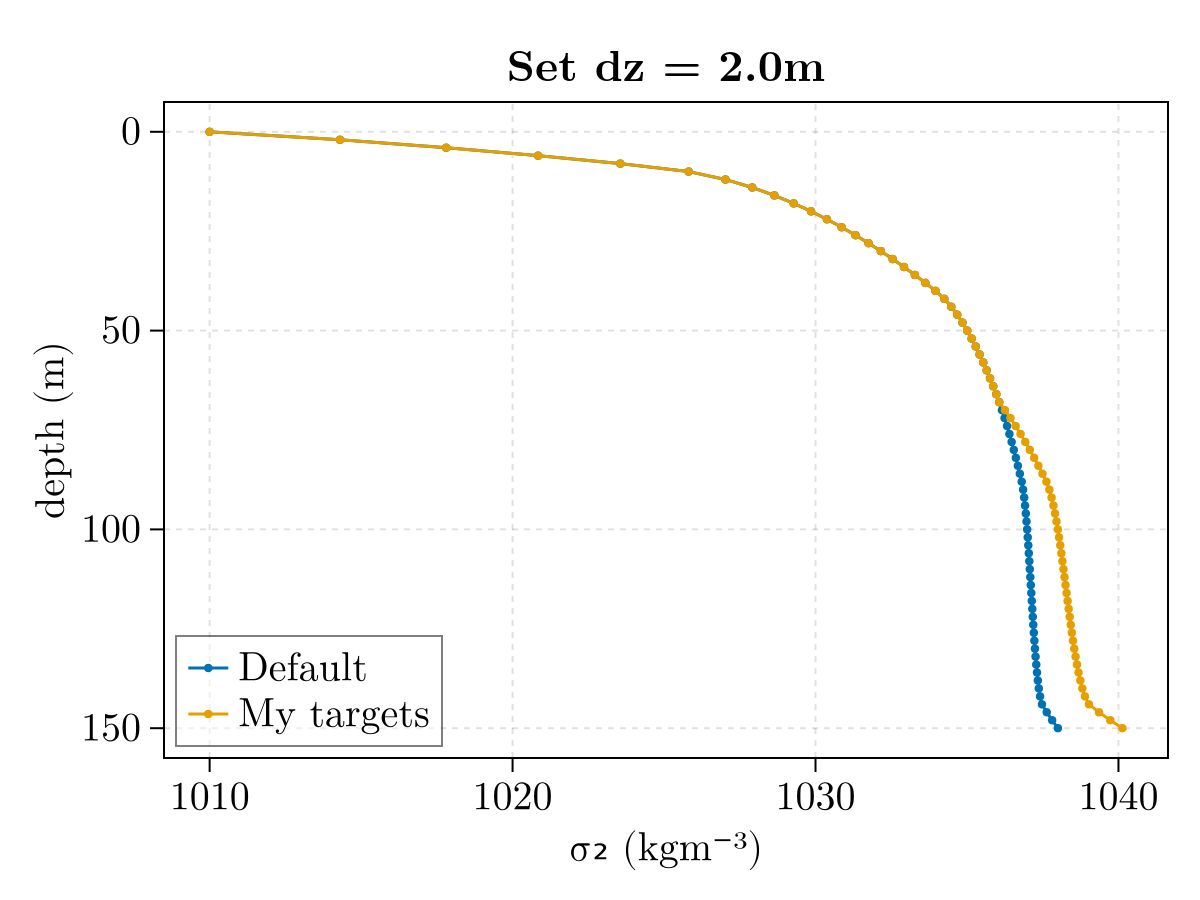

In [116]:
fig, ax = scatterlines(target_densities, interface_depth, label = "Default", markersize = 6)
scatterlines!(ax, my_densities, interface_depth, label = "My targets", markersize = 6)
ax.yreversed = true
ax.xlabel = "σ₂ (kgm⁻³)"
ax.ylabel = "depth (m)"
ax.title = "Set dz = $(dz[1])m"
axislegend(ax, position = :lb)
fig

## Save the file for use with MOM6

In [117]:
ds = NCDataset(hycom_file)
NCDataset(joinpath(pwd(), "hycom1_dz_$(dz)m_deepdensityscale_$(scale).nc"), "c") do new_ds
    defDim(new_ds, "layers", ds.dim["layers"])
    defDim(new_ds, "interfaces", ds.dim["interfaces"])
    defVar(new_ds, "sigma2", my_densities, ("interfaces",), attrib = ds["sigma2"].attrib)
    defVar(new_ds, "dz", dz_array, ("layers",), attrib = ds["dz"].attrib)
    new_ds.attrib["File info"] = "This file rescales the target densities in hycom1_75 to increase by Δσ$(scale) 
                                  increasing the densest water to ~1040kgm⁻³. The dz is uniform, dz = $(dz)m."
    new_ds.attrib["Quasi author"] = "Josef I. Bisits"
end
close(ds)

closed Dataset

Check density file is set correctly.

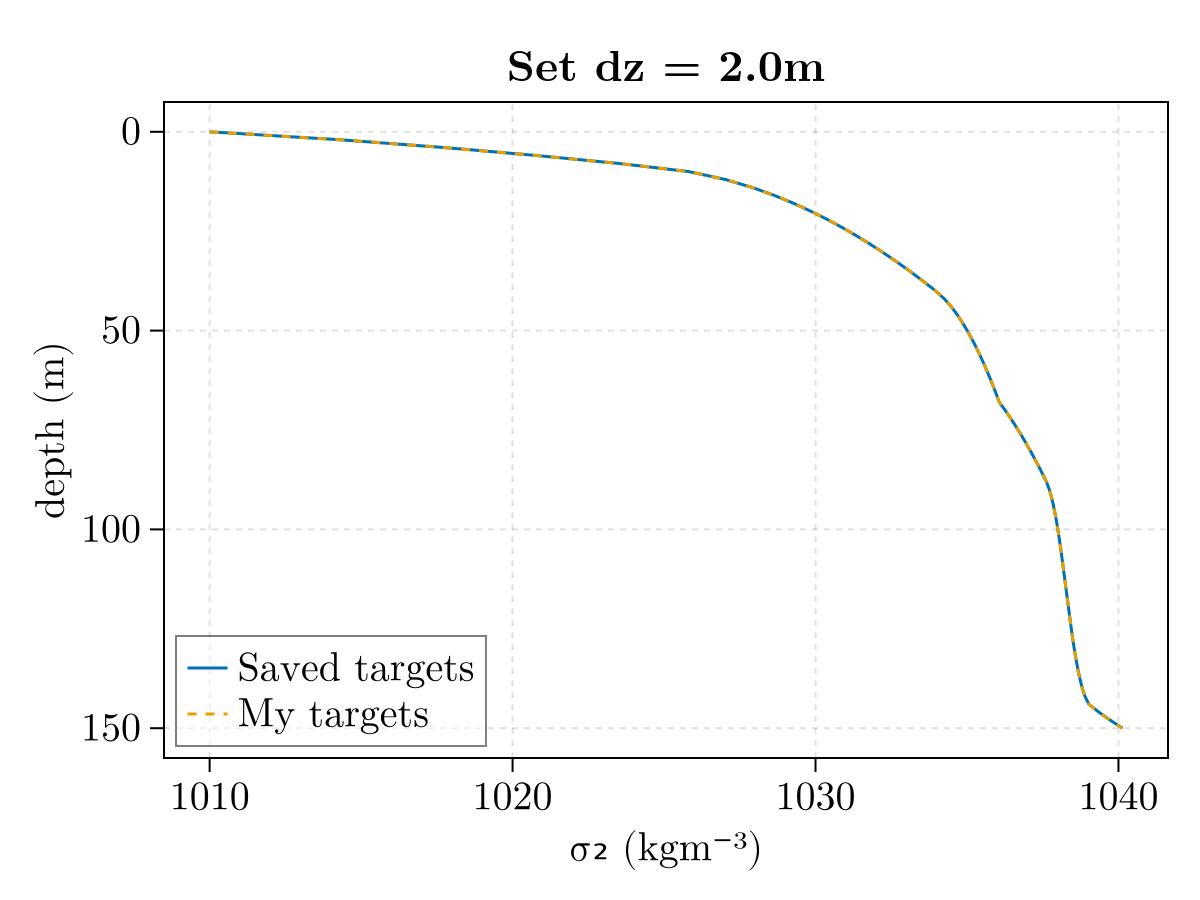

In [121]:
ds = NCDataset("hycom1_dz_2.0m_deepdensityscale_1.1.nc")
dz = ds["dz"][:]
σ = ds["sigma2"][:]
close(ds)

interface_depth = vcat(0, cumsum(dz))

fig, ax = lines(σ, interface_depth, label = "Saved targets")
lines!(ax, my_densities, interface_depth, linestyle = :dash, label = "My targets")
ax.yreversed = true
ax.xlabel = "σ₂ (kgm⁻³)"
ax.ylabel = "depth (m)"
ax.title = "Set dz = $(dz[1])m"
axislegend(ax, position = :lb)
fig

## One month experiment results

Here I will display output from experiments that run for one month to check how a given `hycom1` file works.

In [3]:
expt = "output012_dz2m_denser_deepw"
expt = "output013"

output = joinpath(pwd(), "anu-tub-nm-hycom", expt, "ocean_month.nc")
zoutput = joinpath(pwd(), "anu-tub-nm-hycom", expt, "ocean_month_z.nc")

"/g/data/e14/jb2381/anu-tub/outputs/anu-tub-nm-hycom/output013/ocean_month_z.nc"

In [4]:
ds = NCDataset(zoutput, maskingvalue = NaN)
θ_z = ds["thetao"][:, :, :, end]
σ2_z = ds["rhopot2"][80, :, :, end]
zl = ds["z_l"][:]
zi = ds["z_i"][:]
close(ds)

ds = NCDataset(output, maskingvalue = NaN)
σ2 = ds["rhopot2"][80, :, :, end]
h = ds["thkcello"][80, :, :, end]

nm = mean(nansum(ds["T_advection_scheme_variance_production"][:, :, :, :], dims = 3), dims = 4)[:, :, 1, 1]
nmzm = mean(nansum(ds["T_advection_scheme_variance_production"][:, :, :, :], dims = 1), dims = 4)[1, :, :, 1]
nmzm ./= mean(nansum(ds["thkcello"][:, :, :, :], dims = 1), dims = 4)[1, :, :, 1]

xh = ds["xh"][:]
yh = ds["yh"][:]
z = ds["zl"][:]
close(ds)

ztop = 0.0
interface_depths = Array{Float64}(undef, length(yh),  length(z) + 1)
interface_depths[:, 1] .= ztop
interface_depths[:, 2:end] .= nancumsum(h, dims = 2)
hpoint_depths = 0.5 * (interface_depths[:, 1:end-1] .+ interface_depths[:, 2:end])

println("Maximum density in the density slice: $(nanmaximum(σ2))")

Maximum density in the density slice: 1037.6219482421875


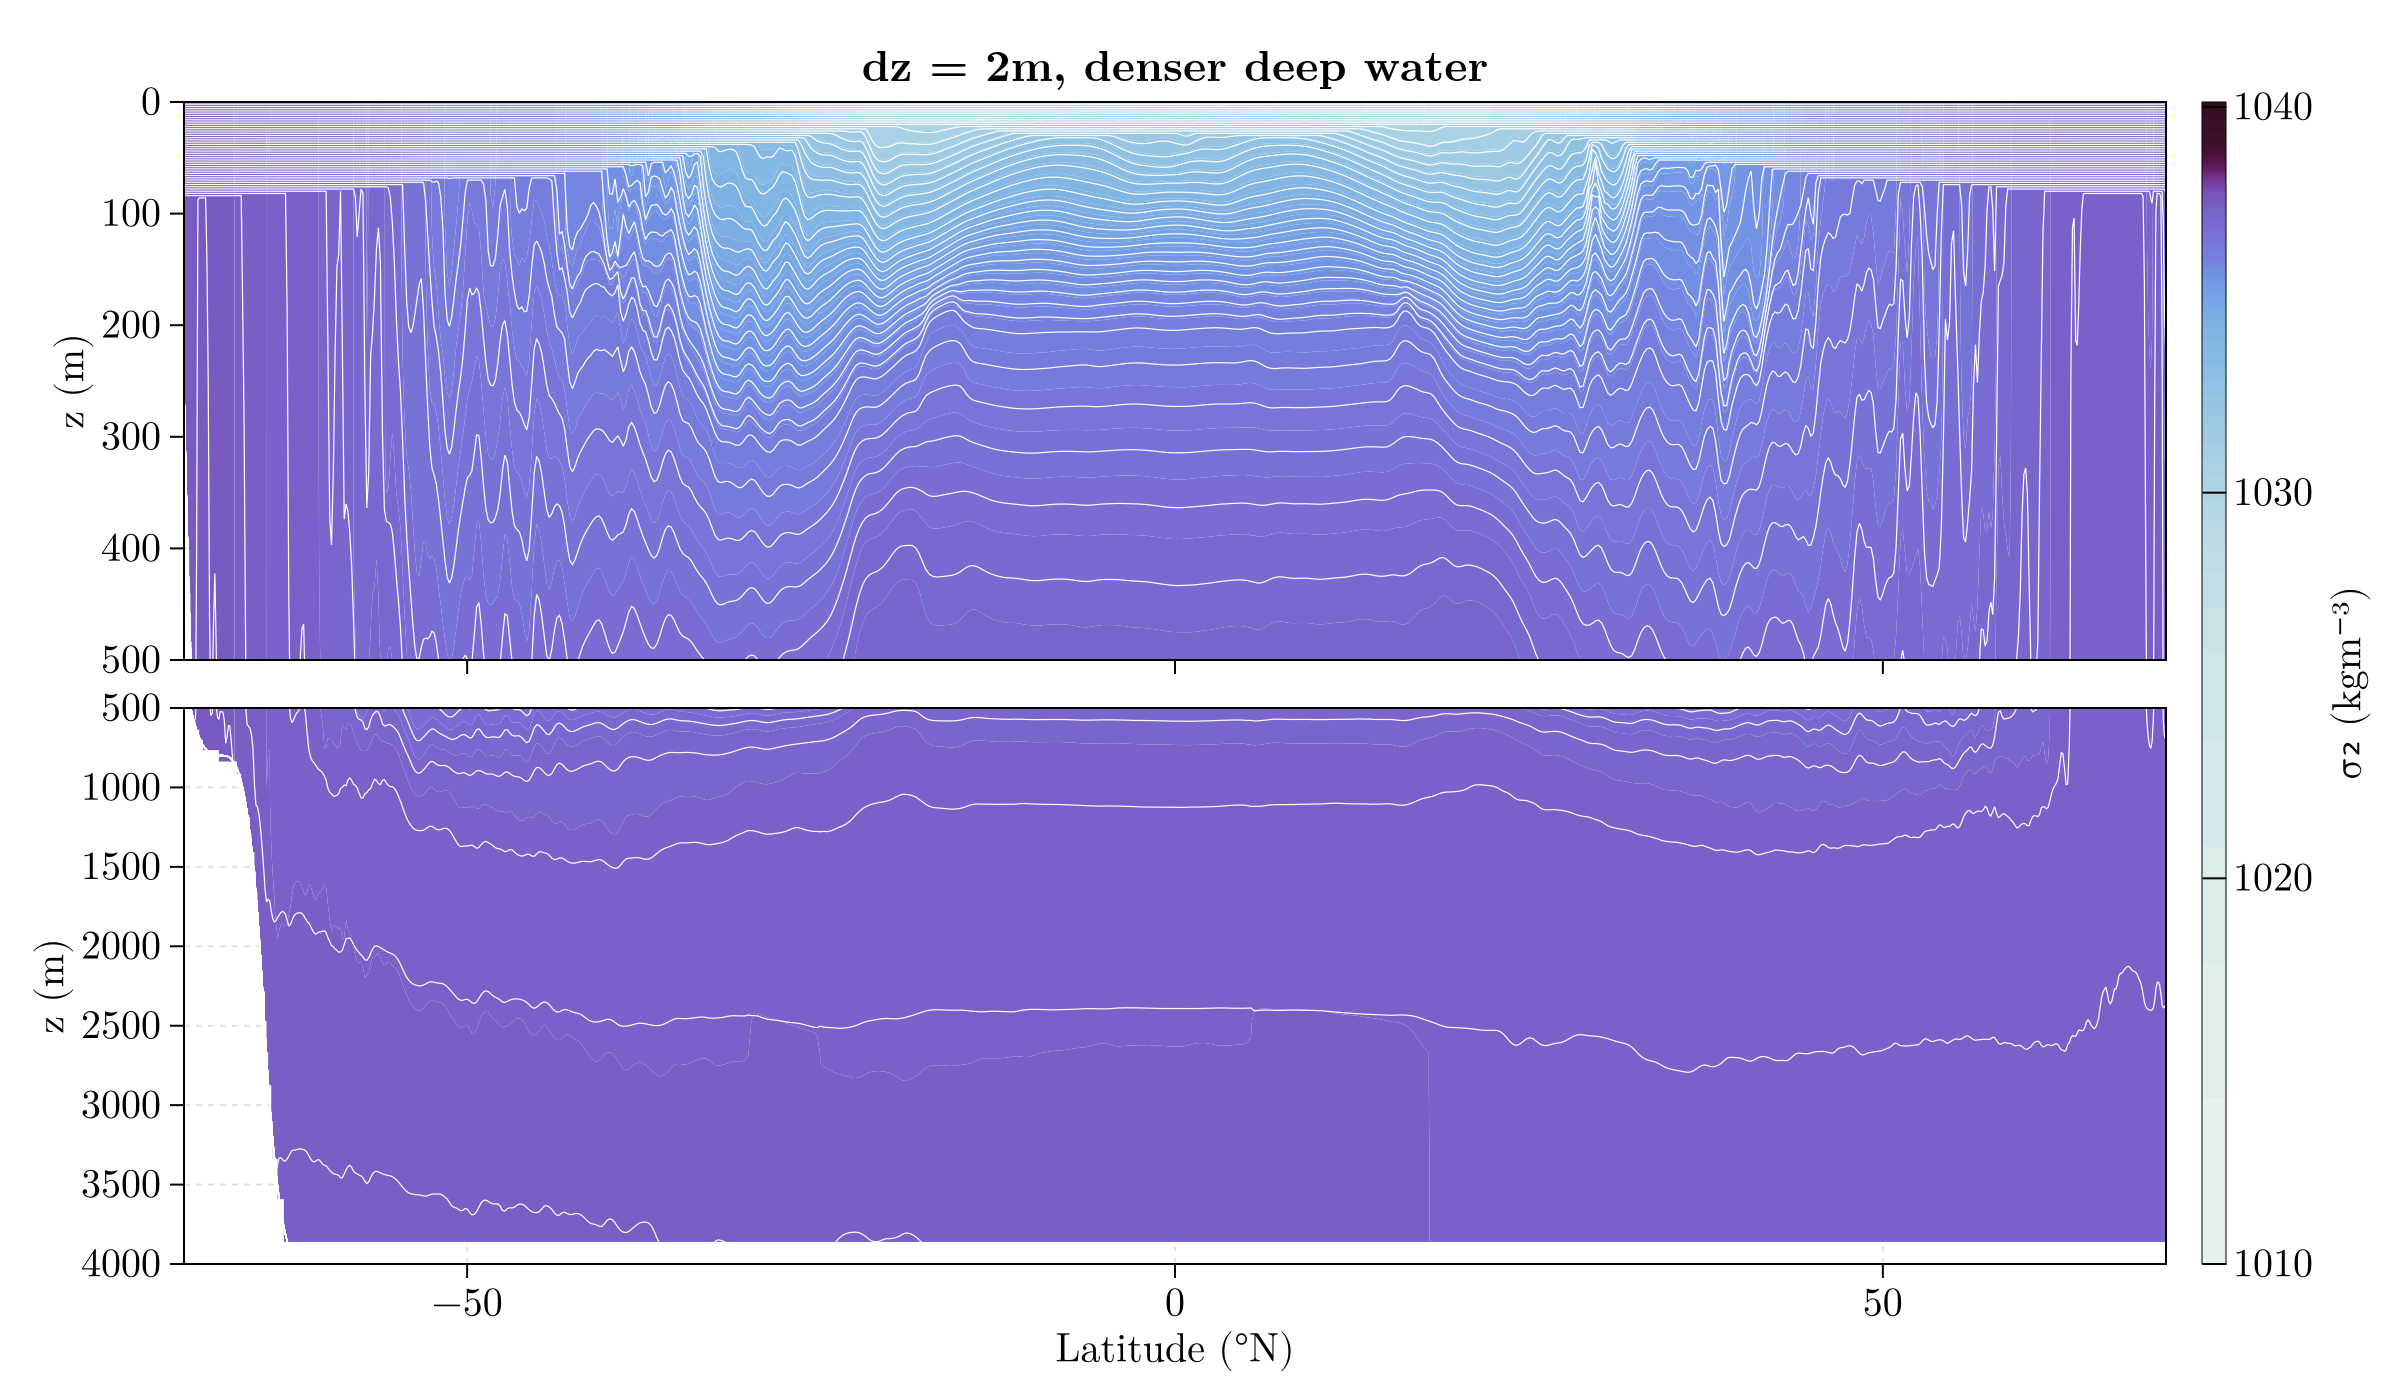

In [7]:
fig = Figure(size = (1200, 700))
colormap = :dense

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "dz = 2m, denser deep water")
hidexdecorations!(axtop, ticks = false)
hm = contourf!(axtop, yh, zl, σ2_z; colormap, levels = my_densities)
for i ∈ axes(interface_depths, 2)
    lines!(axtop, yh, interface_depths[:, i], color = :white, linewidth = 0.6)
end
xlims!(axtop, -70, 70)
ylims!(axtop, 0, 500)
axtop.yreversed = true

axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", yreversed = true)
hm = contourf!(axbot, yh, zl, σ2_z; colormap, levels = my_densities)
for i ∈ axes(interface_depths, 2)
    lines!(axbot, yh, interface_depths[:, i], color = :white, linewidth = 0.6)
end
xlims!(axbot, -70, 70)
ylims!(axbot, 500, 4000)
axbot.yreversed = true

Colorbar(fig[1:2, 2], hm, label = "σ₂ (kgm⁻³)")

fig

**Thoughts:**
- For the extreme example `output012_dz2m_denser_dw` can see that the density surfaces are being found quite well, achieving a better isopycnal structure but have a big gap where there is a large density jump. This is good and indicates that there needs to be a smoother transition between the density jump. Can also see the maximum target density is sinificantly higher in this snapshot, so might be able to reduce this to get a closer spread.

## Numerical mixing

Just looking to see how this changes.

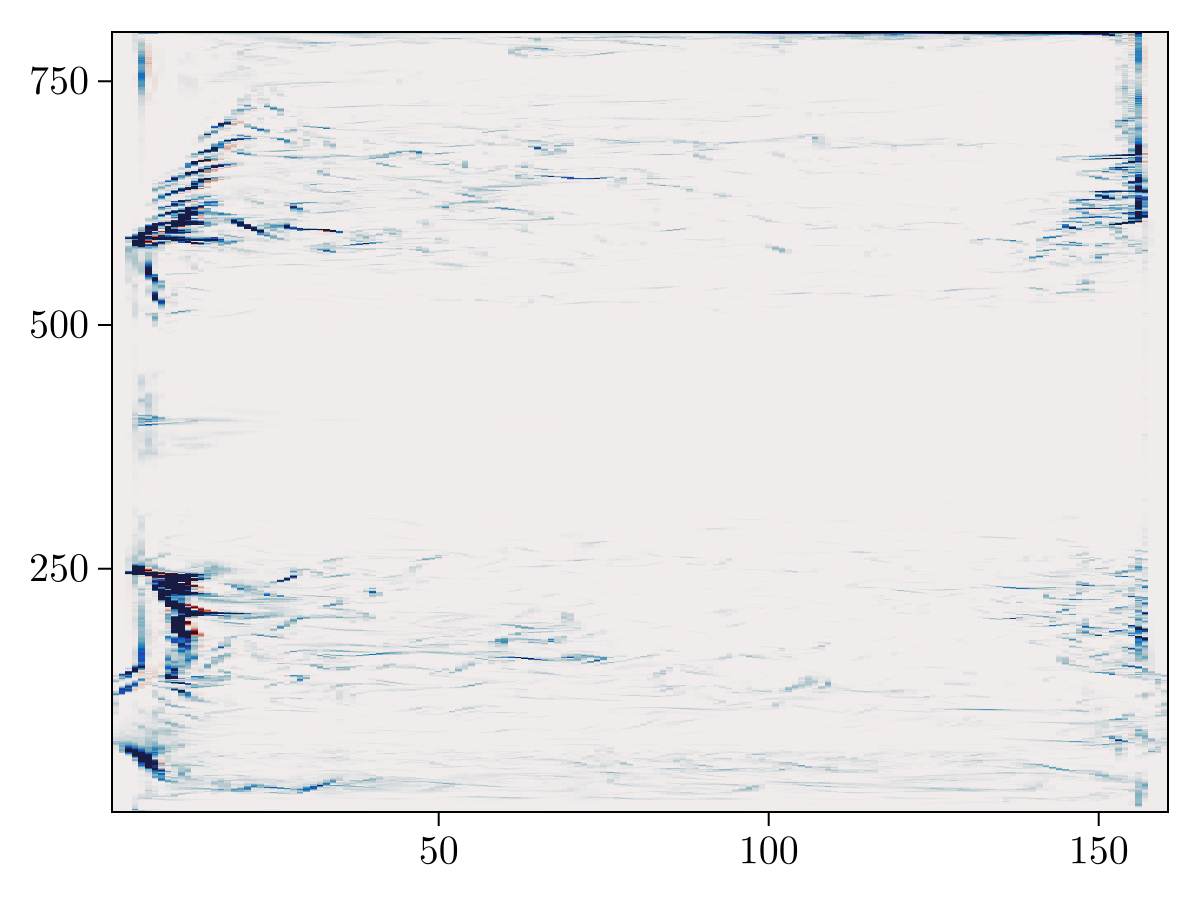

In [8]:
fig, ax, hm = heatmap(nm, colormap = :balance, colorrange = (-5e-4, 5e-4))

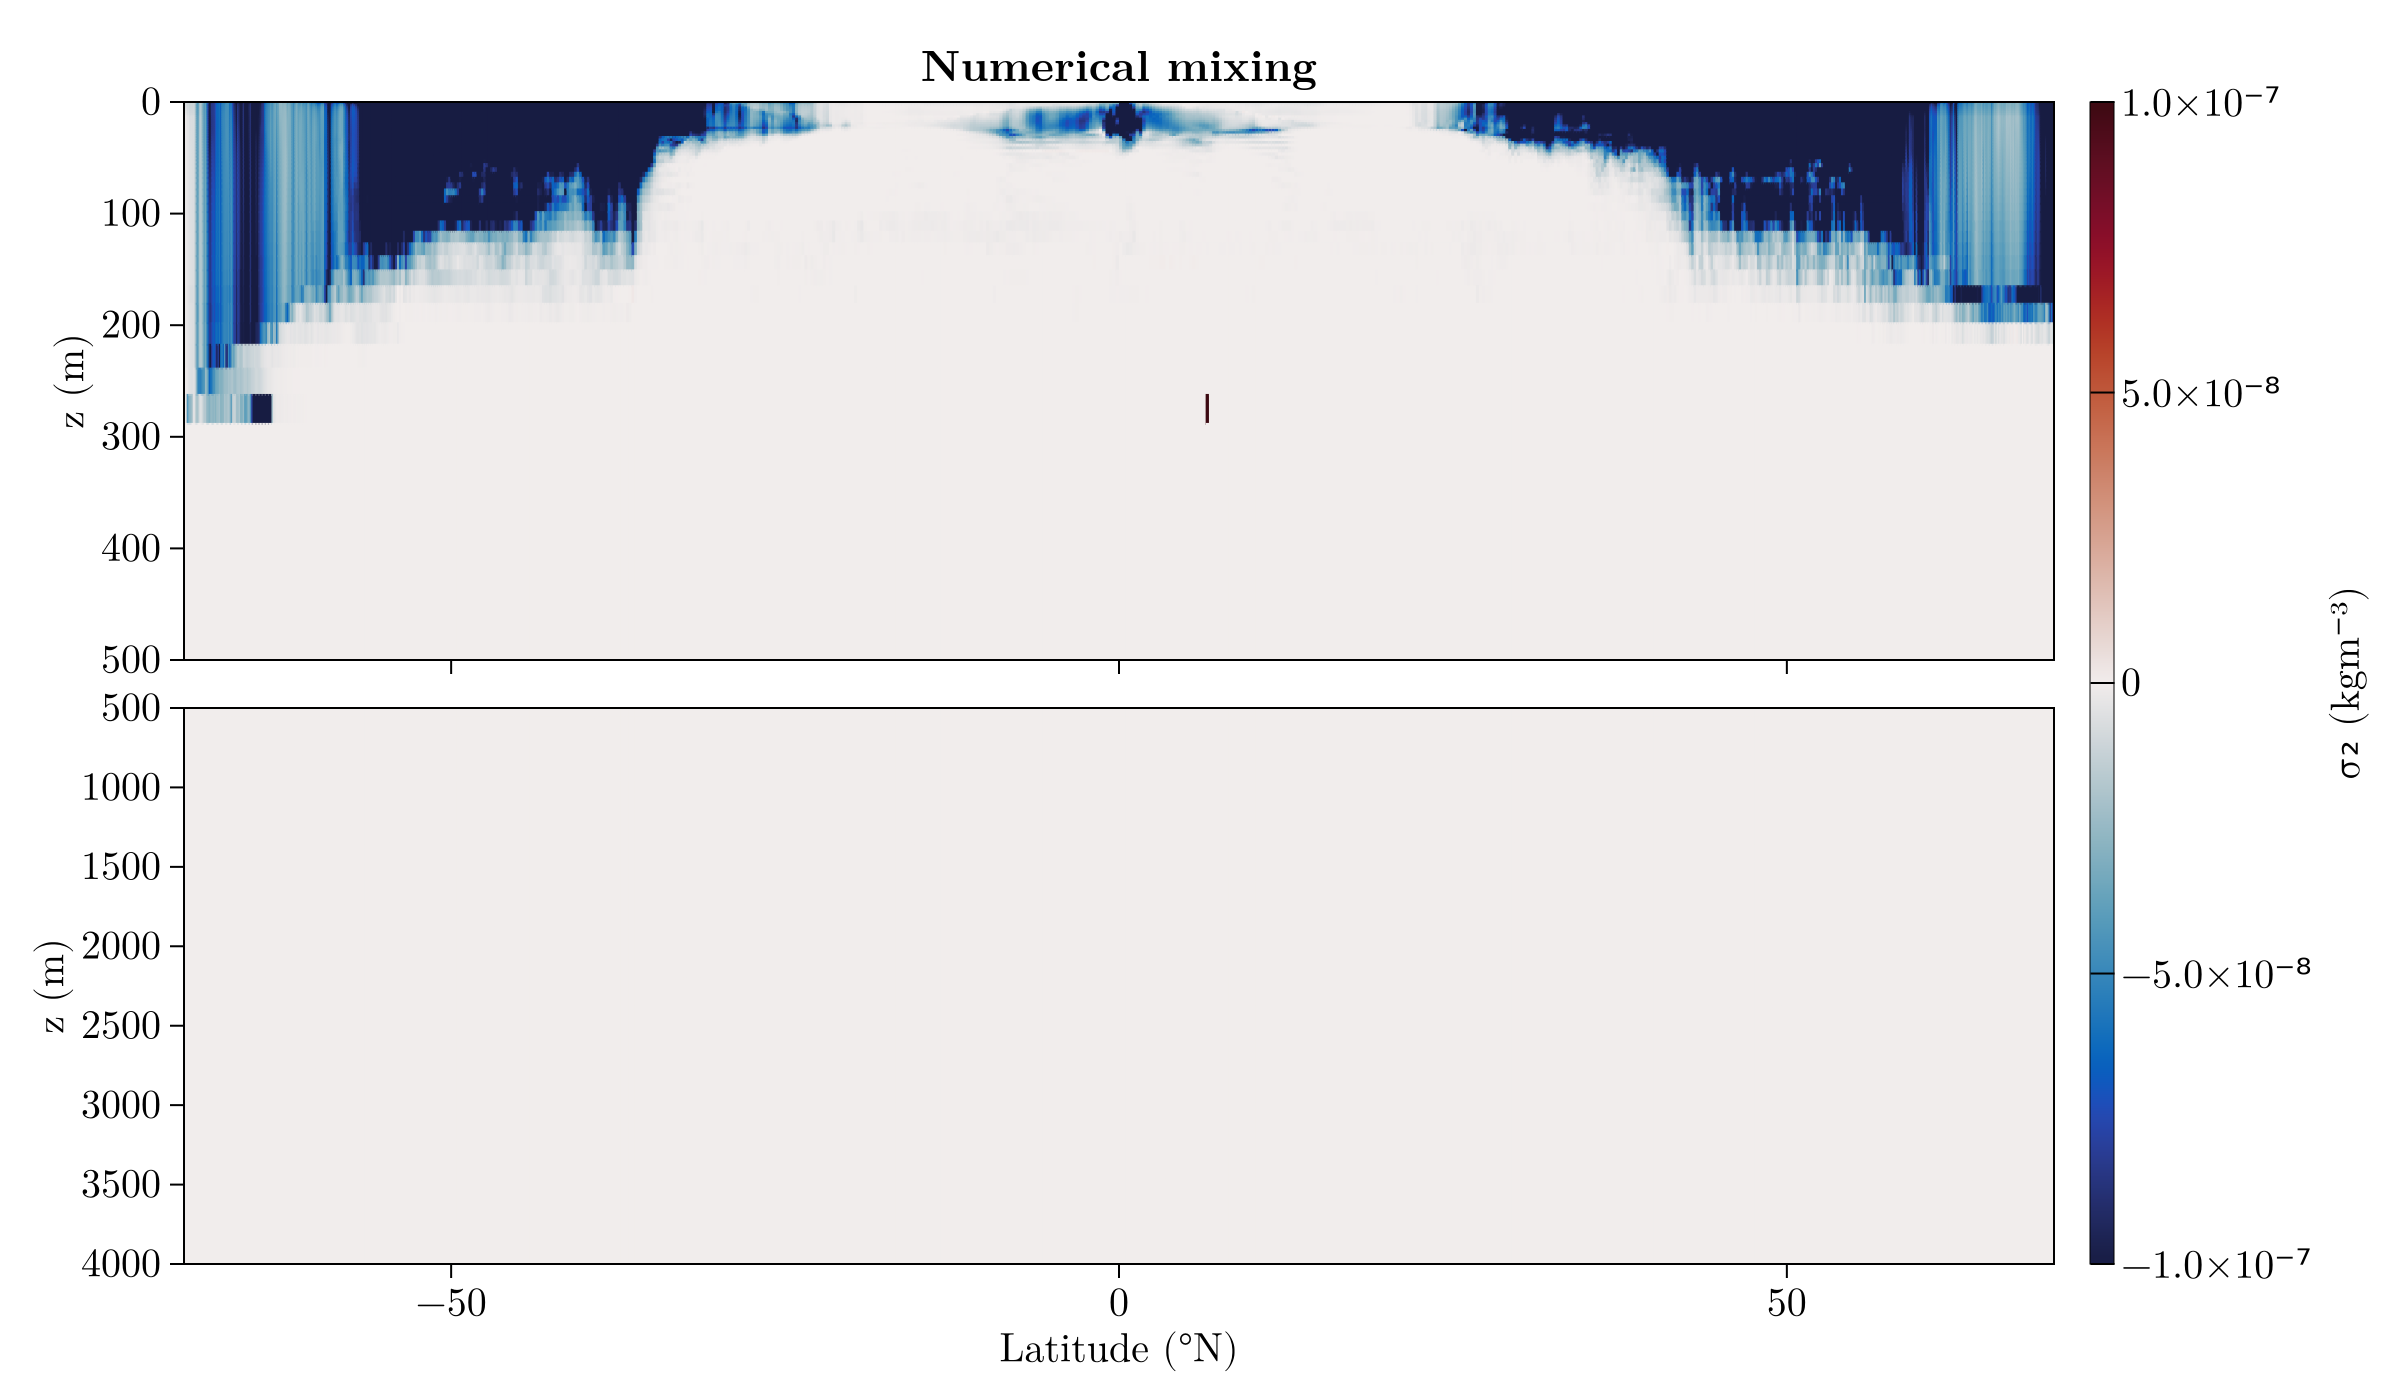

In [12]:
fig = Figure(size = (1200, 700))
colormap = :balance
colorrange = (-1e-7, 1e-7)

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", 
             title = "Numerical mixing")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, zi, nmzm; colormap, colorrange)
# for i ∈ axes(interface_depths, 2)
#     lines!(axtop, yh, interface_depths[:, i], color = :white, linewidth = 0.6)
# end
xlims!(axtop, -70, 70)
ylims!(axtop, 0, 500)
axtop.yreversed = true

axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", yreversed = true)
hm = heatmap!(axbot, yh, zi, nmzm; colormap, colorrange)
# for i ∈ axes(interface_depths, 2)
#     lines!(axbot,  yh, interface_depths[:, i], color = :white, linewidth = 0.6)
# end
xlims!(axbot, -70, 70)
ylims!(axbot, 500, 4000)
axbot.yreversed = true

Colorbar(fig[1:2, 2], hm, label = "σ₂ (kgm⁻³)")

fig